## Homework 6


Name: Acamaro Cutcher

Comments for grader:


### Problem 1: 1D motion with air resistance - 4th order Runge-Kutta

The time rate of change of a falling object with air resistance is:

$$
\frac{dp}{dt} = mg -k v^2
$$

where $p$ is momentum, $v$ is the velocity, $m$ is the mass of the object, $g$ is the acceleration due to gravity, and $k$ is the drag coefficent. For a sphere of mass $10^{-2}$ kg the drag coefficient is $k=10^{-4}$ kg/m.

Letting $p=mv$, use the fourth-order Runge-Kutta method to find the velocity of the sphere released from rest as a function of time for $0 < t < 10 $ seconds. Plot your result against the velocity of an object under-going free-fall.

Calculate the terminal velocity based on the drag coefficient and compare with the terminal velocity you find using your numerical solution.

Solution:

$$
\frac{dp}{dt} = \frac{d mv}{dt} = mg - kv^2
$$
$$
m \frac{dv}{dt} = mg - kv^2
$$
$$
\frac{dv}{dt} = g - \frac{kv^2}{m}
$$

If the change in velocity reaches 0, then the system has reached terminal velocity:
$$
\frac{dv}{dt} = 0
$$
$$
g - \frac{kv^2}{m} = 0
$$
$$
v =\sqrt{\frac{gm}{k}}
$$

Given our paramenters our terminal velocity should be:
$$
v = \sqrt{(9.8 * 10^{-2}/10^{-4})} = 31.30 m/s
$$




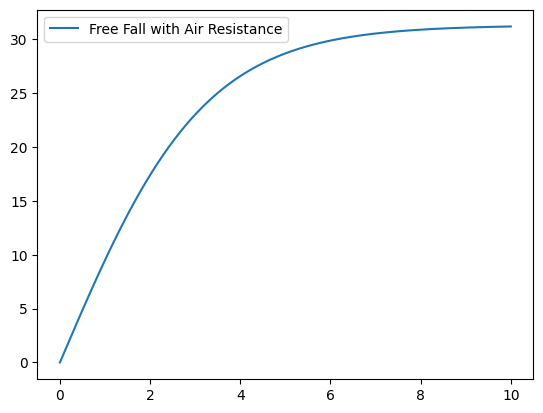

Final Approximation Value obtained using 4th Order RK is:  31.196466834643125 m/s.
The exact solution is:  31.3 m/s.


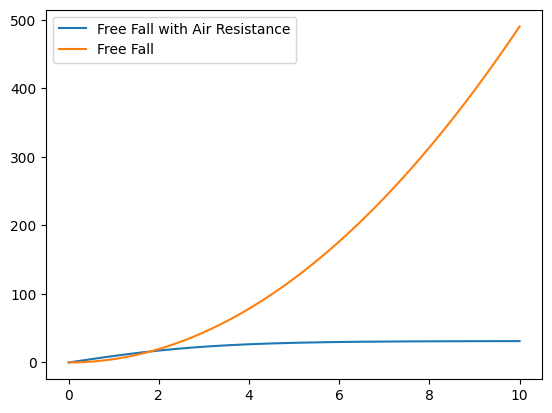

In [8]:
### Type code here
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import g

# Constants
m = 10**(-2)  # kg
k = 10**(-4)  # kg/m


def df(v,t):
    return g - (k * v**2)/m # Drag coefficient!

def free_fall(t):
    return g * t**2 /2  # Initial Velocity is zero!

def rk4(f, t_start, t_end, N_steps, y0):

    h = (t_end - t_start)/ N_steps
    time_steps = np.arange(t_start, t_end + h, h)
    approx_val = np.zeros_like(time_steps)

    approx_val[0] = y0

    for i in range(1, time_steps.shape[0]):
        x = approx_val[i-1]
        t = time_steps[i-1]
        k_1 = h * f(x,t)
        k_2 = h * f(x + 1/2*k_1, t + 1/2 * h)
        k_3 = h * f(x + 1/2*k_2, t + 1/2 * h)
        k_4 = h * f(x + k_3, t + h)
        approx_val[i] = x + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, approx_val

time_steps , approx_vals = rk4(df, 0, 10, 1000, 0)

free_fall_vals = free_fall(time_steps)

plt.plot(time_steps, approx_vals, label="Free Fall with Air Resistance")
plt.legend()
plt.show()

print("Final Approximation Value obtained using 4th Order RK is: ", approx_vals[-1], "m/s.")

print("The exact solution is: ", 31.30, "m/s.")

plt.plot(time_steps, approx_vals, label="Free Fall with Air Resistance")
plt.plot(time_steps, free_fall_vals, label="Free Fall")
plt.legend()
plt.show()


**Analytical terminal velocity: 31.196466834643125 m/s**

**Numerical terminal velocity: 31.3 m/s**

#### Problem 1 Total Pts /15

### Problem 2: The Lorenz equations

**a)** One of the most celebrated sets of differential equations in
physics is the Lorenz equations:
$$
{d x\over d t} = \sigma(y-x),\qquad
{d y\over d t} = \rho x - y - xz,\qquad
{d z\over d t} = xy - bz,
$$

where $\sigma$, $r$, and $b$ are constants.  (The names $\sigma$, $r$,
and $b$ are odd, but traditional---they are always used in these equations
for historical reasons.)

These equations were first studied by Edward Lorenz, Ellen Fetter, and Margaret Hamilton in the 1960s, who
derived them from a simplified model of atmospheric convection. In the original model $x$ is related to the intensity of the convection,
$y$ is proportional to the temperature difference between the rising and falling air currents, and $z$ is determined by the vertical temperature profile.  

The reason for their fame is that they were one of the first incontrovertible
examples of *deterministic chaos*, the occurrence of apparently
random motion even though there is no randomness built into the equations. The system exhibits different behavior based on the choice of the constants.


Write a program to solve the Lorenz equations using the 4th-order Runge-Kutta method for the case
  $\sigma=10$, $r=28$, and $b=\frac83$ in the range from $t=0$ to $t=50$
  with initial conditions $(x,y,z)=(0,1,0)$.  You will have to use a large number of time steps, otherwise the solution blows up.
  
Have your program make the following plots. Label each appropriately.  
1. $y$ as a function of time.  Note the unpredictable nature of the motion.
2. $z$ against $x$.  You should see a picture of the famous ``strange attractor'' of the Lorenz equations, a lopsided butterfly-shaped plot that never repeats itself.

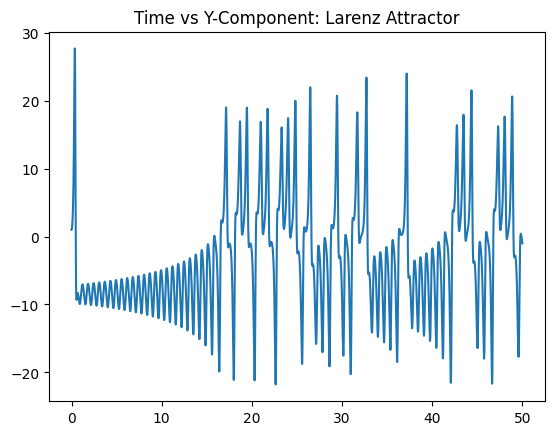

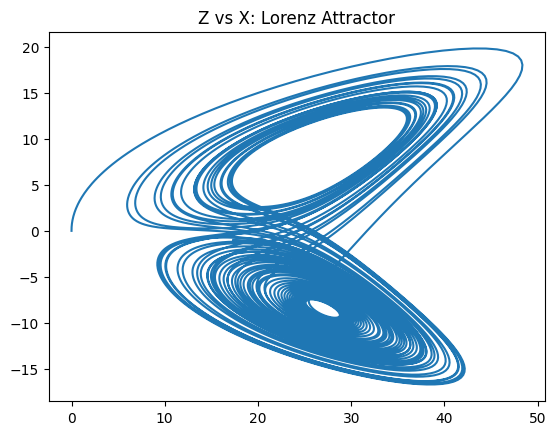

In [13]:
### Type Problem part a) code here
import numpy as np
import matplotlib.pyplot as plt

def df(r, t): # Added 't' as an argument
    sigma = 10
    rho = 28
    b = 8/3

    dx = sigma*(r[1] - r[0])
    dy = rho*r[0]- r[1] -r[0]*r[2]
    dz = r[0]*r[1] - b * r[2]

    return np.array([dx, dy, dz])

def rk4(f, t_start, t_end, N_steps, r0):

    h = (t_end - t_start)/N_steps
    time_steps = np.arange(t_start, t_end + h, h) # Renamed to time_steps for consistency

    r_approx = np.zeros((N_steps+1, 3)) # Correctly initialized as a 2D array of zeros
    r_approx[0]  = r0

    for i in range(1, time_steps.shape[0]):

        t = time_steps[i-1]
        r = r_approx[i-1]

        k_1 = h * f(r,t)
        k_2 = h * f(r + 1/2*k_1, t + 1/2 * h)
        k_3 = h * f(r + 1/2*k_2, t + 1/2 * h)
        k_4 = h * f(r + k_3, t + h)
        r_approx[i] = r + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, r_approx

r0 = np.array([0,1,0])

time_steps, r_approx = rk4(df,0, 50, 10000, r0)

plt.plot(time_steps, r_approx[:,1])
plt.title("Time vs Y-Component: Larenz Attractor")
plt.show()

plt.plot(r_approx[:, 2], r_approx[:, 0])
plt.title("Z vs X: Lorenz Attractor")
plt.show()

**Pts /10**

**b)** Repeat part **a** using the same constants, but this time compute solutions for three slightly different starting conditions by perturbing the initial condition for $y$ by $\pm 1\times 10^{-5}$. Plot the trajectories of all three solutions together on a 3D graph using, for example:

```
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z, 'green')
```

where $x,y,z$ contain your solutions. Use different colors for each initial condition.

Also plot the initial and final locations of each trajectory with large markers. Note because the paths of the trajectories may block your markers, you may wish to only plot the trajectories near their ends to reveal the end points.


What do you observe? How does this demonstrate chaotic behavior?

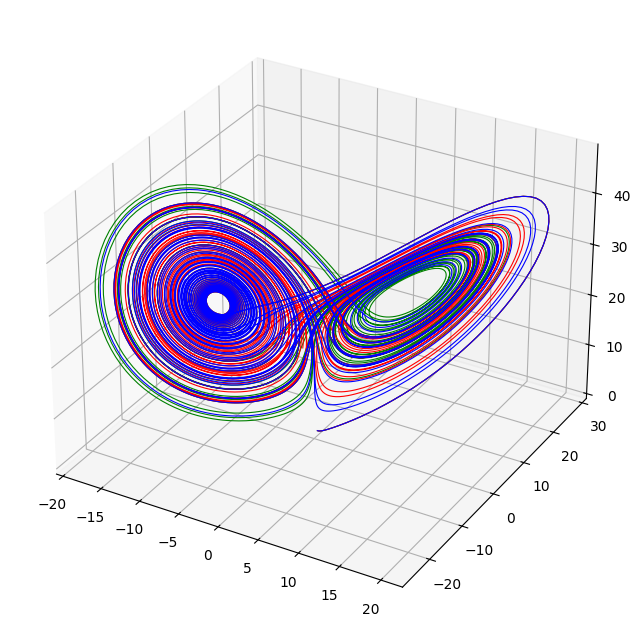

In [ ]:
## Type problem part b) here
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np

def df(r, t): # Added 't' as an argument
    sigma = 10
    rho = 28
    b = 8/3

    dx = sigma*(r[1] - r[0])
    dy = rho*r[0]- r[1] -r[0]*r[2]
    dz = r[0]*r[1] - b * r[2]

    return np.array([dx, dy, dz])

def rk4(f, t_start, t_end, N_steps, r0):

    h = (t_end - t_start)/N_steps
    time_steps = np.arange(t_start, t_end + h, h) # Renamed to time_steps for consistency

    r_approx = np.zeros((N_steps+1, 3)) # Correctly initialized as a 2D array of zeros
    r_approx[0]  = r0

    for i in range(1, time_steps.shape[0]):

        t = time_steps[i-1]
        r = r_approx[i-1]

        k_1 = h * f(r,t)
        k_2 = h * f(r + 1/2*k_1, t + 1/2 * h)
        k_3 = h * f(r + 1/2*k_2, t + 1/2 * h)
        k_4 = h * f(r + k_3, t + h)
        r_approx[i] = r + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, r_approx
eps = 1e-5

r0 = np.array([0,1 - eps,0])
time_steps_1, r_approx_1 = rk4(df,0, 50, 10000, r0)

r0 = np.array([0,1,0])
time_steps_2, r_approx_2 = rk4(df,0, 50, 10000, r0)

r0 = np.array([0,1 + eps,0])
time_steps_3, r_approx_3 = rk4(df,0, 50, 10000, r0)

fig = plt.figure(figsize=(10, 8)) # Make the figure bigger
ax = plt.axes(projection='3d')
x = r_approx_1[:,0]
y = r_approx_1[:,1]
z = r_approx_1[:,2]
ax.plot3D(x,y,z, 'green', linewidth=0.8) # Set a smaller linewidth

x = r_approx_2[:,0]
y = r_approx_2[:,1]
z = r_approx_2[:,2]
ax.plot3D(x,y,z, 'red', linewidth=0.8) # Set a smaller linewidth

x = r_approx_3[:,0]
y = r_approx_3[:,1]
z = r_approx_3[:,2]
ax.plot3D(x,y,z, 'blue', linewidth=0.8) # Set a smaller linewidth


**Pts /10**

#### Problem 2 Total Pts /20

### Homework points /35 pts